In [1]:
# Credit Worthiness Prediction

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


df = pd.read_csv("Credit_Score_Classification_Updated.csv")

# Feature Engineering
df = df.drop("Customer Code", axis=1)

# Encode categorical columns
label_encoders = {}

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and Target
X = df.drop("Credit Score", axis=1)
y = df["Credit Score"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

# Training and Evaluation

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\n===================================")
    print(name)
    print("===================================")

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

    # ROC-AUC
    try:
        y_prob = model.predict_proba(X_test)
        roc = roc_auc_score(
            y_test,
            y_prob,
            multi_class='ovr'
        )
        print("ROC-AUC  :", roc)
    except:
        print("ROC-AUC  : Not Available")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00         3

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33

Confusion Matrix
[[ 7  0  0]
 [ 0 23  0]
 [ 0  0  3]]

Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00         3

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighte

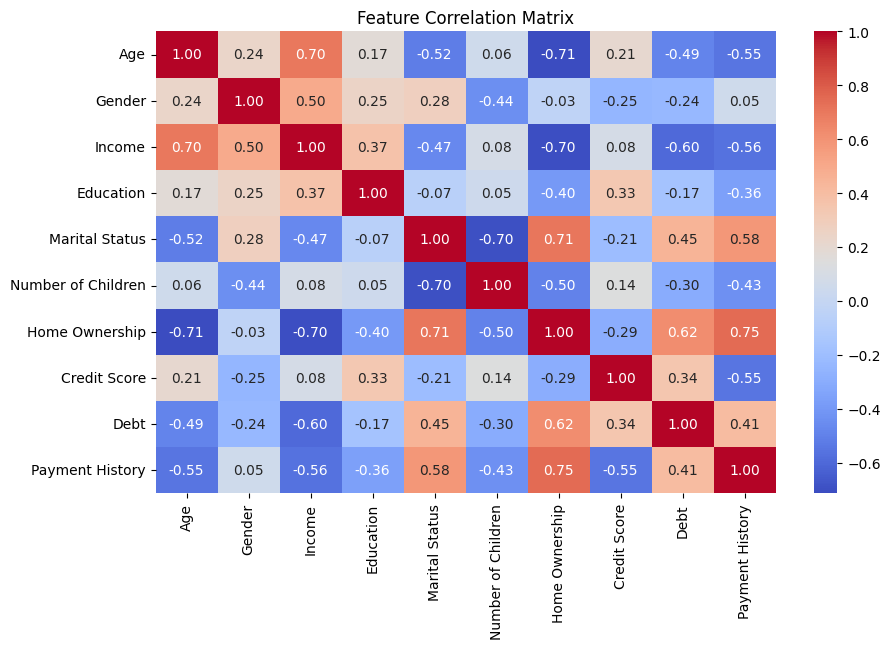

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check correlations with the target variable
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [3]:
# Drop the top two dominating features
X_dropped = X.drop(["Payment History", "Debt"], axis=1)

#  Re-split the data using the new feature set
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dropped, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain and evaluate on the new feature set
print("--- Performance WITHOUT Payment History & Debt ---")
for name, model in models.items():
    # Use original clean y_train_d labels here
    model.fit(X_train_d, y_train_d)
    y_pred = model.predict(X_test_d)
    
    print(f"\n{name}:")
    print(f"  Accuracy : {accuracy_score(y_test_d, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_test_d, y_pred, average='weighted'):.4f}")

--- Performance WITHOUT Payment History & Debt ---


C:\Users\Anmol\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression:
  Accuracy : 0.9697
  F1 Score : 0.9715

Decision Tree:
  Accuracy : 1.0000
  F1 Score : 1.0000

Random Forest:
  Accuracy : 1.0000
  F1 Score : 1.0000


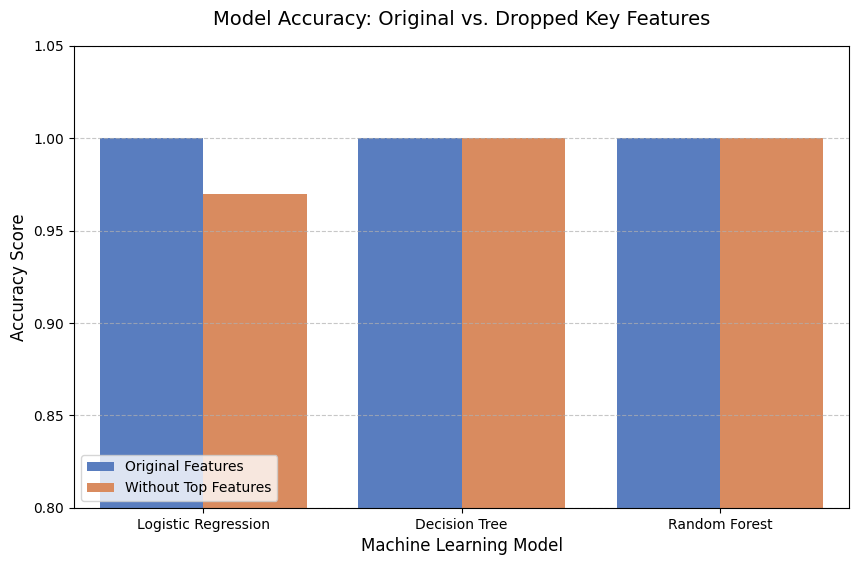

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Create a summary dataframe of your results
data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"] * 2,
    "Accuracy": [1.0000, 1.0000, 1.0000, 0.9697, 1.0000, 1.0000],
    "Dataset": ["Original Features", "Original Features", "Original Features", 
                "Without Top Features", "Without Top Features", "Without Top Features"]
}
res_df = pd.DataFrame(data)

# 2. Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", hue="Dataset", data=res_df, palette="muted")
plt.ylim(0.8, 1.05)
plt.title("Model Accuracy: Original vs. Dropped Key Features", fontsize=14, pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Machine Learning Model", fontsize=12)
plt.legend(loc="lower left")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [7]:
def predict_user_credit_score(model, label_encoders, original_features):
    print("--- Enter Customer Details for Prediction ---")
    user_data = {}
    
    for col in original_features:
       
        if col in label_encoders:
            valid_classes = list(label_encoders[col].classes_)
            print(f"\nAvailable options for {col}: {valid_classes}")
            val = input(f"Enter {col}: ").strip()
           
            while val not in valid_classes:
                print(f"Invalid input. Please choose from: {valid_classes}")
                val = input(f"Enter {col}: ").strip()
                
            
            user_data[col] = label_encoders[col].transform([val])[0]
        else:
       
            try:
                user_data[col] = float(input(f"Enter numerical value for {col}: "))
            except ValueError:
                print("Invalid number. Defaulting to 0.")
                user_data[col] = 0.0


    input_df = pd.DataFrame([user_data])
    
 
    prediction_encoded = model.predict(input_df)[0]
    

    print("\n===================================")
    print(f"Predicted Credit Score Class: {prediction_encoded}")
    print("===================================")
    
    return prediction_encoded


predict_user_credit_score(models["Random Forest"], label_encoders, X_dropped.columns)

--- Enter Customer Details for Prediction ---


Enter numerical value for Age:  33



Available options for Gender: ['Female', 'Male']


Enter Gender:  male


Invalid input. Please choose from: ['Female', 'Male']


...

Enter Marital Status:  Single
Enter numerical value for Number of Children:  3



Available options for Home Ownership: ['Owned', 'Rented']


Enter Home Ownership:  Owned



Predicted Credit Score Class: 1


np.int64(1)